In [6]:
import json
import os
from pathlib import Path
import numpy as np
import cv2
import pycocotools.mask as mask_util

In [7]:
def load_frame_json(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data

def decode_rle_to_mask(rle):
    """
    Accepts compressed or uncompressed RLE dicts.
    Returns a binary mask of shape (H, W), dtype uint8, values {0,1}.
    """
    m = mask_util.decode(rle)  # returns uint8 {0,1}, shape (H, W) or (H, W, N)
    if m.ndim == 3:
        # If multiple instances stacked in third dimension, combine
        m = np.max(m, axis=2)
    m = 1-m
    return m.astype(np.uint8)

def overlay_mask_on_image_bgr(img_bgr, mask, color=(0, 0, 255), alpha=0.5):
    """
    img_bgr: HxWx3 (OpenCV BGR)
    mask: HxW binary (0/1)
    color: BGR color for mask overlay
    alpha: blending strength (0..1)
    Returns blended image.
    """
    # Create a color layer
    color_layer = np.zeros_like(img_bgr, dtype=np.uint8)
    color_layer[mask == 1] = color

    # Alpha blend only where mask==1
    blended = img_bgr.copy()
    idx = mask.astype(bool)
    blended[idx] = (
        (alpha * color_layer[idx].astype(np.float32) +
         (1 - alpha) * blended[idx].astype(np.float32))
        .clip(0, 255)
        .astype(np.uint8)
    )
    return blended

def draw_outline(img_bgr, mask, color=(0, 255, 255), thickness=2):
    """
    Optional: draw an outline around masked region.
    """
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(img_bgr, contours, -1, color, thickness)
    return img_bgr

def overlay_from_json(json_path, out_path=None,
                      per_object_colors=None, invert_mask = True, alpha=0.5,
                      outline=False, outline_color=(0,255,255), outline_thickness=2):
    """
    Reads one frame JSON, overlays all masks onto base image, writes or returns result.
    - per_object_colors: list of BGR tuples, one per annotation; if None, uses a default palette.
    """
    data = load_frame_json(json_path)
    img_path = data["image_path"]
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Could not read base image: {img_path}")

    annotations = data.get("annotations", [])
    if not annotations:
        print(f"No annotations found in {json_path}. Returning base image.")
        result = img

    else:
        # Default color palette (repeats if more objects)
        default_palette = [
            (0, 0, 255),    # red
            (0, 255, 0),    # green
            (255, 0, 0),    # blue
            (0, 255, 255),  # yellow
            (255, 0, 255),  # magenta
            (255, 255, 0),  # cyan
            (128, 0, 128),  # purple
        ]

        result = img.copy()
        for i, ann in enumerate(annotations):
            seg = ann["segmentation"]
            mask = decode_rle_to_mask(seg)  # HxW uint8 {0,1}

            color = (
                per_object_colors[i]
                if per_object_colors and i < len(per_object_colors)
                else default_palette[i % len(default_palette)]
            )

            result = overlay_mask_on_image_bgr(result, mask, color=color, alpha=alpha)
            if outline:
                result = draw_outline(result, mask, color=outline_color, thickness=outline_thickness)

    if out_path:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        cv2.imwrite(out_path, result)
        print(f"Saved overlay to: {out_path}")
    return result


In [8]:
masks_dir = Path("/home/prince/repo/Grounded-SAM-2/output/")

In [9]:
frame_idx = 200
frame_idx_str = str(frame_idx).zfill(5) 
json_path = masks_dir / f"{frame_idx_str}.json"
out_dir= Path("output")
out_path = Path(out_dir / "overlay.png").resolve()
# out_path.mkdir(exist_ok=True)

In [10]:

per_object_colors = [(0,0,255), (0,255,0), (255,0,0)]  # BGR for ann0, ann1, ann2


In [ ]:

overlay_from_json(
    json_path=json_path,
    out_path=out_path,
    invert_mask=True,
    per_object_colors=per_object_colors,
    alpha=0.6,
    outline=True,
    outline_color=(0,255,255),
    outline_thickness=2
)

Saved overlay to: /home/prince/proj/chicken-behaviour-classifier/notebook/output/overlay.png


array([[[  0, 255, 255],
        [  0, 255, 255],
        [  0, 255, 255],
        ...,
        [  0, 255, 255],
        [  0, 255, 255],
        [  0, 255, 255]],

       [[  0, 255, 255],
        [  0, 255, 255],
        [  0, 255, 255],
        ...,
        [  0, 255, 255],
        [  0, 255, 255],
        [  0, 255, 255]],

       [[  0, 255, 255],
        [  0, 255, 255],
        [  0,   3, 155],
        ...,
        [  1,   3, 156],
        [  0, 255, 255],
        [  0, 255, 255]],

       ...,

       [[  0, 255, 255],
        [  0, 255, 255],
        [  0,   3, 155],
        ...,
        [  2,   3, 156],
        [  0, 255, 255],
        [  0, 255, 255]],

       [[  0, 255, 255],
        [  0, 255, 255],
        [  0, 255, 255],
        ...,
        [  0, 255, 255],
        [  0, 255, 255],
        [  0, 255, 255]],

       [[  0, 255, 255],
        [  0, 255, 255],
        [  0, 255, 255],
        ...,
        [  0, 255, 255],
        [  0, 255, 255],
        [  0, 255, 255]]

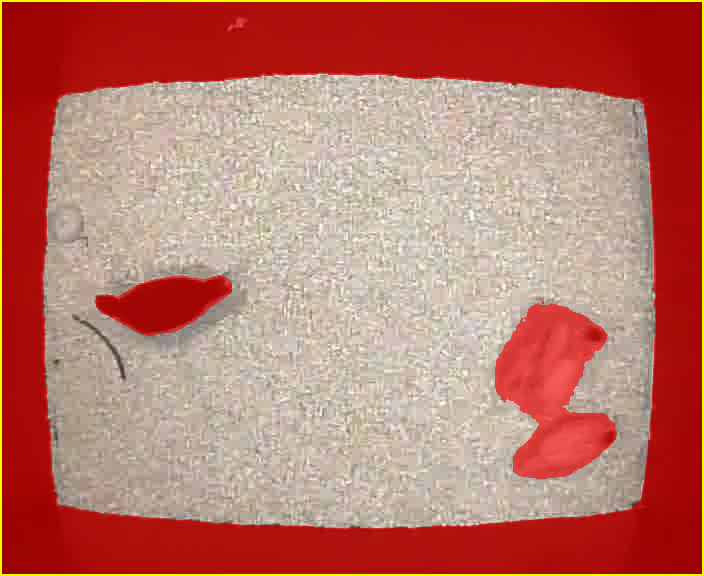

In [17]:
from IPython.display import Image

Image("/home/prince/proj/chicken-behaviour-classifier/notebook/output/overlay.png")